# Notebook 01: Download & Parse

**One Sensor, One Year — Edition 2: Texas Grid**

First contact with the ERCOT Fuel Mix Report. Goals:
- Download the raw XLSX from ERCOT (only on first run)
- Parse all 12 monthly sheets into one tidy DataFrame
- Build daily totals (one row per date × fuel — straight from the `Total` column)
- Build a 15-minute → hourly time series (melt the 96 interval columns)
- Standardize column names (lowercase fuel types)
- Filter to calendar year 2025, check for gaps
- Save processed CSVs

**Data source:** [ERCOT Generation Info](https://www.ercot.com/gridinfo/generation) — `IntGenbyFuel2025.xlsx` (~3 MB), last updated 2026-03-09. Earlier years live in a separate ZIP archive that we'll pull only when notebook 06 needs YoY context.

**Format note:** ERCOT publishes monthly tabs in **wide form** — one row per `(Date, Fuel)` with a `Total` column followed by 96 columns labelled `0:15`, `0:30`, …, `23:45`, `0:00`. The trailing `0:00` is the *end* of interval 96 (= midnight of the next day). The 10 fuels are: Biomass, Coal, Gas, Gas-CC, Hydro, Nuclear, Other, Solar, WSL, Wind. Values are MWh per 15-minute settlement interval. Four extra `(DST)` columns appear for the November fall-back day — handled separately below.

Raw downloads are gitignored — this notebook re-fetches them as needed.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

YEAR = 2025
XLSX_URL = 'https://www.ercot.com/files/docs/2025/02/07/IntGenbyFuel2025.xlsx'
XLSX_PATH = RAW / f'IntGenbyFuel{YEAR}.xlsx'

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

## 1. Download raw data (one-time)

ERCOT publishes the current year as a standalone XLSX (~3 MB). Skipped if it's already on disk.

In [2]:
if not XLSX_PATH.exists():
    print(f'Downloading {XLSX_URL} ...')
    r = requests.get(XLSX_URL, stream=True, timeout=120)
    r.raise_for_status()
    with open(XLSX_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1 << 16):
            f.write(chunk)
    print(f'Saved {XLSX_PATH} ({XLSX_PATH.stat().st_size / 1e6:.1f} MB)')
else:
    print(f'Already have {XLSX_PATH} ({XLSX_PATH.stat().st_size / 1e6:.1f} MB)')

Saved ../data/raw/IntGenbyFuel2025.xlsx (3.0 MB)


## 2. Inspect file structure

Typically 16 sheets: 4 metadata sheets (`Disclaimer`, `Summary`, `data_Summary_1`, `data_Summary_2`) plus 12 monthly tabs (`Jan` … `Dec`). We only care about the monthly tabs.

In [3]:
all_sheet_names = pd.ExcelFile(XLSX_PATH).sheet_names
print(f'All sheets ({len(all_sheet_names)}): {all_sheet_names}\n')

jan = pd.read_excel(XLSX_PATH, sheet_name='Jan')
print(f"Sheet 'Jan' shape: {jan.shape}")
print(f'First 5 columns: {jan.columns.tolist()[:5]}')
print(f'Last 5 columns:  {jan.columns.tolist()[-5:]}')
print(f'Unique fuels:    {sorted(jan["Fuel"].unique())}')
print(f'Settlement Type: {jan["Settlement Type"].unique().tolist()}')
print()
jan.head(3)

All sheets (16): ['Disclaimer', 'Summary', 'data_Summary_1', 'data_Summary_2', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']



Sheet 'Jan' shape: (310, 100)
First 5 columns: ['Date', 'Fuel', 'Settlement Type', 'Total', '0:15']
Last 5 columns:  ['23:00', '23:15', '23:30', '23:45', '0:00']
Unique fuels:    ['Biomass', 'Coal', 'Gas', 'Gas-CC', 'Hydro', 'Nuclear', 'Other', 'Solar', 'WSL', 'Wind']
Settlement Type: ['FINAL']



,Date,Fuel,Settlement Type,Total,0:15,0:30,0:45,1:00,1:15,1:30,...,21:45,22:00,22:15,22:30,22:45,23:00,23:15,23:30,23:45,0:00
0,2025-01-01,Biomass,FINAL,292.796362,3.054841,3.049060,3.054768,3.053916,3.051822,3.050287,...,3.043416,3.047293,3.050419,3.053479,3.048874,3.049250,3.041998,3.045390,3.042455,3.048085
1,2025-01-01,Coal,FINAL,160852.712431,1635.159759,1591.098918,1555.589102,1518.956907,1506.565087,1498.083757,...,2544.737369,2478.274254,2484.827570,2528.484231,2519.822711,2427.722893,2343.066828,2182.004392,2029.453319,1934.772915
2,2025-01-01,Gas,FINAL,33392.590576,222.914735,224.037142,224.465410,232.559316,221.941085,203.545873,...,628.790845,553.815907,449.286368,386.106044,338.973933,306.413563,296.518679,296.895584,296.136862,296.505007


## 3. Parse all 12 monthly sheets

Read only the 12 month tabs (skip metadata sheets) and concatenate.

In [4]:
monthly = pd.read_excel(XLSX_PATH, sheet_name=MONTHS)
print(f'Loaded {len(monthly)} monthly sheets')

raw = pd.concat(monthly.values(), ignore_index=True)
raw['Date'] = pd.to_datetime(raw['Date'])
print(f'Combined: {raw.shape[0]} rows, {raw.shape[1]} columns')
print(f'Date range: {raw["Date"].min().date()} → {raw["Date"].max().date()}')
print(f'Unique fuels: {sorted(raw["Fuel"].unique())}')
print(f'Sanity: 365 days × 10 fuels = {365*10} expected, got {len(raw)}')

Loaded 12 monthly sheets
Combined: 3650 rows, 104 columns
Date range: 2025-01-01 → 2025-12-31
Unique fuels: ['Biomass', 'Coal', 'Gas', 'Gas-CC', 'Hydro', 'Nuclear', 'Other', 'Solar', 'WSL', 'Wind']
Sanity: 365 days × 10 fuels = 3650 expected, got 3650


## 4. Build the daily table

Each row already has a `Total` column = sum of its 96 quarter-hour intervals (plus the 4 DST quarter-hours on the November fall-back day) = MWh for that fuel on that calendar day. Pivot `Date × Fuel` straight from `Total` — no melting needed.

In [5]:
rename_map = {
    'Coal':    'coal',
    'Gas':     'gas',         # simple-cycle / steam gas
    'Gas-CC':  'gas_cc',      # combined-cycle gas (the workhorse)
    'Nuclear': 'nuclear',
    'Hydro':   'hydro',
    'Wind':    'wind',
    'Solar':   'solar',
    'Biomass': 'biomass',
    'Other':   'other',
    'WSL':     'wsl',         # storage net (negative when charging)
}

daily = (
    raw.pivot_table(index='Date', columns='Fuel', values='Total', aggfunc='sum')
       .rename(columns=rename_map)
       .sort_index()
)
daily.columns.name = None

# Combined gas (CC + simple) is the headline number
daily['gas_total'] = daily[['gas', 'gas_cc']].sum(axis=1, min_count=1)

# Total generation excludes WSL (storage net, not generation)
GEN_COLS = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
daily['total'] = daily[GEN_COLS].sum(axis=1, min_count=1)

print(f'Daily shape: {daily.shape}')
print(f'Columns: {daily.columns.tolist()}')
daily.head()

Daily shape: (365, 12)
Columns: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wsl', 'wind', 'gas_total', 'total']


,biomass,coal,gas,gas_cc,hydro,nuclear,other,solar,wsl,wind,gas_total,total
Date,,,,,,,,,,,,
2025-01-01,292.796362,160852.712431,33392.590576,392943.040304,799.300791,122009.869343,11770.418412,146729.160664,-12125.698021,234138.509198,426335.630880,1.102928e+06
2025-01-02,298.855389,207305.928419,49677.692111,429615.579997,862.531788,122080.055087,11132.706371,98232.155457,-14243.803994,243637.744930,479293.272108,1.162843e+06
2025-01-03,354.828444,215368.252870,42884.689529,420293.663532,1014.426645,122096.610508,10450.898963,107655.848302,-13078.744523,202267.479041,463178.353061,1.122387e+06
2025-01-04,353.449159,126122.109895,22864.549994,221772.461472,404.073020,122041.276713,5085.313824,45266.698101,-13093.722168,534207.972536,244637.011466,1.078118e+06
2025-01-05,368.514137,127774.767068,34229.757116,265332.644661,939.041796,121981.615278,4255.592727,53919.988912,-6067.397578,535183.154815,299562.401777,1.143985e+06


## 5. Build the hourly table (for the signature deep-dive in notebook 18)

Melt the 96 standard interval columns to long form, parse each `H:MM` header into a real timestamp, then pivot to `(timestamp × fuel)` and resample to hourly.

**DST handling:** ERCOT runs on Central Time. The fall-back day (Nov 2 2025) has 4 extra columns labelled `01:15 (DST)` … `02:00 (DST)` for the duplicate hour. We drop them here — losing one hour of generation in the hourly view (~0.01% of the year). The daily table above keeps them via the `Total` column, so daily totals remain exact.

In [6]:
TIME_COLS = [c for c in raw.columns
             if isinstance(c, str) and ':' in c and '(DST)' not in c]
DST_COLS = [c for c in raw.columns if isinstance(c, str) and '(DST)' in c]
print(f'{len(TIME_COLS)} standard interval columns ({TIME_COLS[0]} … {TIME_COLS[-1]})')
print(f'{len(DST_COLS)} DST interval columns (dropped from hourly): {DST_COLS}')

long = raw.melt(
    id_vars=['Date', 'Fuel'],
    value_vars=TIME_COLS,
    var_name='time_str',
    value_name='mwh',
)

# Parse 'H:MM' → (hour, minute). The '0:00' column is the END of interval 96 = next-day midnight.
hm = long['time_str'].str.split(':', expand=True).astype(int)
long['hour'] = hm[0]
long['minute'] = hm[1]
is_next_day = (long['hour'] == 0) & (long['minute'] == 0)
long['timestamp'] = (
    long['Date']
    + pd.to_timedelta(long['hour'], unit='h')
    + pd.to_timedelta(long['minute'], unit='m')
    + pd.to_timedelta(is_next_day.astype(int), unit='D')
)

fifteen = (
    long.pivot_table(index='timestamp', columns='Fuel', values='mwh', aggfunc='sum')
        .rename(columns=rename_map)
        .sort_index()
)
fifteen.columns.name = None
fifteen['gas_total'] = fifteen[['gas', 'gas_cc']].sum(axis=1, min_count=1)

print(f'15-min shape: {fifteen.shape}')
print(f'Range: {fifteen.index.min()} → {fifteen.index.max()}')
fifteen.head()

96 standard interval columns (0:15 … 0:00)
4 DST interval columns (dropped from hourly): ['01:15 (DST)', '01:30 (DST)', '01:45 (DST)', '02:00 (DST)']


15-min shape: (35040, 11)
Range: 2025-01-01 00:15:00 → 2026-01-01 00:00:00


,biomass,coal,gas,gas_cc,hydro,nuclear,other,solar,wsl,wind,gas_total
timestamp,,,,,,,,,,,
2025-01-01 00:15:00,3.054841,1635.159759,222.914735,4356.562359,1.033143,1271.441126,2.713811,0.000012,-194.077677,3536.617372,4579.477094
2025-01-01 00:30:00,3.049060,1591.098918,224.037142,4359.891349,1.033923,1271.023989,1.570692,0.000012,-193.709565,3573.464001,4583.928491
2025-01-01 00:45:00,3.054768,1555.589102,224.465410,4359.030173,1.034740,1271.482283,1.220092,0.000012,-249.695136,3649.335367,4583.495583
2025-01-01 01:00:00,3.053916,1518.956907,232.559316,4384.863310,1.034923,1271.547756,2.382973,0.000018,-316.258660,3697.360457,4617.422626
2025-01-01 01:15:00,3.051822,1506.565087,221.941085,4305.975761,1.035145,1271.389902,5.493074,0.000018,-196.847508,3711.303210,4527.916846


In [7]:
# Resample 15-min → hourly (sum of 4 quarter-hour intervals, labelled by hour ending)
hourly = fifteen.resample('1h', label='right', closed='right').sum(min_count=1)
hourly['total'] = hourly[GEN_COLS].sum(axis=1, min_count=1)

print(f'Hourly shape: {hourly.shape}')
hourly.head()

Hourly shape: (8760, 12)


,biomass,coal,gas,gas_cc,hydro,nuclear,other,solar,wsl,wind,gas_total,total
timestamp,,,,,,,,,,,,
2025-01-01 01:00:00,12.212585,6300.804686,903.976603,17460.347191,4.136729,5085.495154,7.887568,0.000054,-953.741038,14456.777197,18364.323794,44231.637767
2025-01-01 02:00:00,12.209287,5933.170200,779.668395,17087.262470,4.144082,5082.505730,35.232043,0.000060,-708.372924,14953.004805,17866.930865,43887.197072
2025-01-01 03:00:00,12.210014,5703.709650,690.397178,16735.795688,18.986033,5081.178951,121.955904,0.000054,-757.950159,15358.778866,17426.192866,43723.012338
2025-01-01 04:00:00,12.209218,5743.478337,870.191834,16655.985524,7.177729,5082.003580,163.664148,0.000066,-807.762013,15095.464246,17526.177358,43630.174682
2025-01-01 05:00:00,12.211151,5837.164066,1053.433294,16968.743636,4.146167,5081.753758,113.450870,0.000066,-207.353496,14574.489296,18022.176930,43645.392304


## 6. Filter to calendar year 2025 + missing data check

In [8]:
daily25 = daily.loc[f'{YEAR}-01-01':f'{YEAR}-12-31'].copy()
# Hours labelled 01:00 (end of first hour) through next-Jan-01 00:00 (end of last hour of YEAR)
hourly25 = hourly.loc[f'{YEAR}-01-01 01:00':f'{YEAR+1}-01-01 00:00'].copy()

print(f'Daily {YEAR}:  {len(daily25)} rows (expect 365 — not a leap year)')
print(f'Hourly {YEAR}: {len(hourly25)} rows (expect 8760)')

expected_days = pd.date_range(f'{YEAR}-01-01', f'{YEAR}-12-31', freq='D')
missing_days = expected_days.difference(daily25.index)
print(f'Missing days: {len(missing_days)}')
for d in missing_days:
    print(f'  {d.date()} ({d.strftime("%A")})')

nans = daily25.isnull().sum()
print(f'\nNaN counts (daily {YEAR}):')
for col, count in nans.items():
    if count > 0:
        print(f'  {col:12s}: {count}')
if nans.sum() == 0:
    print('  No missing values.')

Daily 2025:  365 rows (expect 365 — not a leap year)
Hourly 2025: 8760 rows (expect 8760)
Missing days: 0

NaN counts (daily 2025):
  No missing values.


## 7. First look — daily generation mix in 2025

Stacked area, 7-day rolling average. Same colour conventions as Edition 1 so the editions stay visually comparable side-by-side.

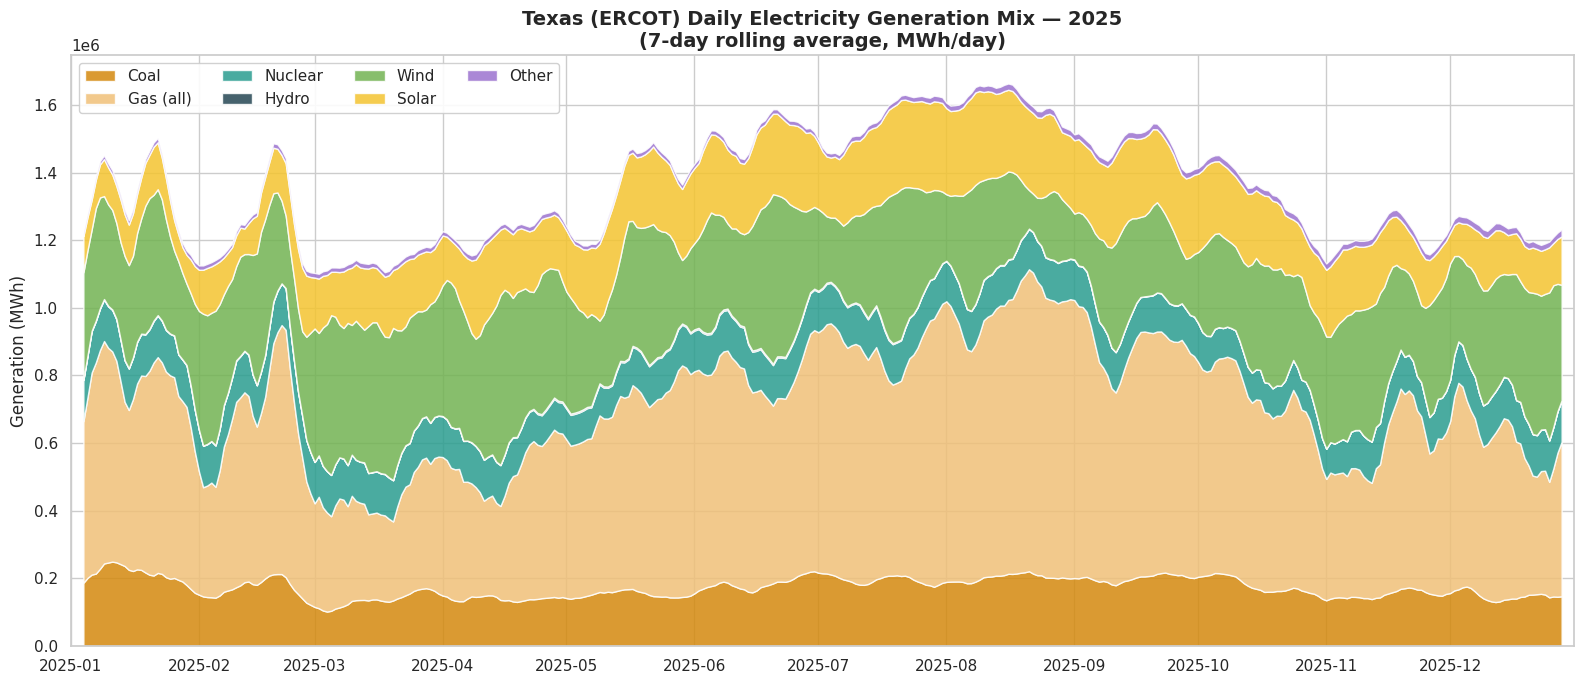

Saved ../data/processed/first_look_2025.png


In [9]:
stack_order = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'other']

fuel_colors = {
    'coal':      '#D4890E',  # warm amber (matches Edition 1)
    'gas_total': '#F0C078',  # light orange — Texas's dominant fuel
    'nuclear':   '#2A9D8F',  # teal
    'hydro':     '#264653',  # deep blue
    'wind':      '#72B352',  # green
    'solar':     '#F4C430',  # golden yellow
    'other':     '#9B72CF',  # soft purple
}
fuel_labels = {
    'coal': 'Coal', 'gas_total': 'Gas (all)', 'nuclear': 'Nuclear',
    'hydro': 'Hydro', 'wind': 'Wind', 'solar': 'Solar', 'other': 'Other',
}

plot_data = daily25[stack_order].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 7))
ax.stackplot(
    plot_data.index,
    *[plot_data[c] for c in stack_order],
    labels=[fuel_labels[c] for c in stack_order],
    colors=[fuel_colors[c] for c in stack_order],
    alpha=0.85,
)
ax.set_title(f"Texas (ERCOT) Daily Electricity Generation Mix — {YEAR}\n(7-day rolling average, MWh/day)",
             fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Generation (MWh)')
ax.legend(loc='upper left', ncol=4, framealpha=0.9)
ax.set_xlim(plot_data.index.min(), plot_data.index.max())

plt.tight_layout()
plt.savefig(PROCESSED / f'first_look_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {PROCESSED / f"first_look_{YEAR}.png"}')

## 8. Save processed data

In [10]:
daily25.to_csv(PROCESSED / f'texas_{YEAR}_daily.csv')
print(f'Saved texas_{YEAR}_daily.csv: {len(daily25)} rows')

hourly25.to_csv(PROCESSED / f'texas_{YEAR}_hourly.csv')
print(f'Saved texas_{YEAR}_hourly.csv: {len(hourly25)} rows')

Saved texas_2025_daily.csv: 365 rows
Saved texas_2025_hourly.csv: 8760 rows


## Key findings (fill in after first run)

1. ERCOT 2025 reports 10 fuels: Coal, Gas, Gas-CC, Nuclear, Hydro, Wind, Solar, Biomass, Other, WSL.
2. Gas-CC (combined cycle) is the workhorse — far larger than simple-cycle Gas. We carry both columns plus a `gas_total = gas + gas_cc` for headline plots.
3. WSL has negative values when storage is charging — excluded from `total` so generation never goes negative.
4. Each row's `Total` column already equals the sum of its 96 quarter-hour intervals (+ 4 DST intervals on the fall-back day) — used directly for daily, no melt needed.
5. The hourly view drops the 4 DST quarter-hours, so the year's hourly grid has 8760 evenly-spaced hours with no ambiguous-time gymnastics.
6. Compare with India's 2024 stacked area (`editions/india-breathes/data/processed/first_look_2024.png`) — coal-dominant vs gas-dominant should jump out immediately.

→ Next: Notebook 02 — Basic Statistics